# **1.Data Collection**

In [ ]:
import pandas as pd

data = pd.read_csv("/content/diamonds.csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


# **Data Understanding**

In [ ]:
#data.shape
data.describe().T
#data.info()
#data.columns
#data.dtypes
#data.head()
#data.tail()
#data.price.value_counts()

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [ ]:
data['price'].value_counts()

,count
price,
605,132
802,127
625,126
828,125
776,124
...,...
2769,1
9033,1
9027,1


In [ ]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## **Data Cleaning, Data Preprocessing & Transformation**

In [ ]:
# Handle missing values: Drop or impute.
data.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
# Find BOTH NaN + Zero together
data[
    (data['x'].isnull()) | (data['x'] == 0) |
    (data['y'].isnull()) | (data['y'] == 0) |
    (data['z'].isnull()) | (data['z'] == 0)
].count()

,0
carat,20
cut,20
color,20
clarity,20
depth,20
table,20
price,20
x,20
y,20
z,20


In [ ]:
# Replace 0 with NaN
import numpy as np

num_cols = data.select_dtypes(include='number').columns
data[num_cols] = data[num_cols].replace(0, np.nan)

In [ ]:
# Fill Na with mean
#num_cols = data.select_dtypes(include='number').columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

In [ ]:
# Find BOTH NaN + Zero together for all the cols
print(num_cols)

#data[(data['price_inr'].isnull()) | (data['price_inr'] == 0) ]

#data[(data['price'].isnull()) | (data['price'] == 0) ]

#data[(data['table'].isnull()) | (data['table'] == 0) ]

#data[(data['depth'].isnull()) | (data['depth'] == 0) ]

data[(data['clarity'].isnull()) | (data['clarity'] == 0) ]





Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z'], dtype='object')


,carat,cut,color,clarity,depth,table,price,x,y,z


In [ ]:
# Find all the Categorical cols
cat_cols = data.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['cut', 'color', 'clarity'], dtype='object')


In [ ]:
data[cat_cols].isnull().sum()

,0
cut,0
color,0
clarity,0


In [ ]:
# Find BOTH NaN + Zero together for all the categorical cols

#data[(data['cut'].isnull()) | (data['cut'] == 0)]
#data[(data['color'].isnull()) | (data['color'] == 0)]
data[(data['clarity'].isnull()) | (data['clarity'] == 0)]

,carat,cut,color,clarity,depth,table,price,x,y,z


In [ ]:
# Handle Missing Values in Categorical Columns

for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_1843/614095157.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
data[cat_cols].describe().T

,count,unique,top,freq
cut,53940,5,Ideal,21551
color,53940,7,G,11292
clarity,53940,8,SI1,13065


In [ ]:
# Standardize of Categarical data.

print(data['cut'].unique())
print(data['color'].unique())
print(data['clarity'].unique())

for col in cat_cols:
    print(col, data[col].unique())

['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
['E' 'I' 'J' 'H' 'F' 'G' 'D']
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']
cut ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
color ['E' 'I' 'J' 'H' 'F' 'G' 'D']
clarity ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


In [ ]:
# If required
#data['Cover_Type'] = data['Cover_Type'].str.strip().str.title() # .strip() - Removes leading and trailing whitespace (spaces, tabs, etc.) -> "  pine forest  "  →  "pine forest"
                                                                #  .title() - Converts the string to Title Case (first letter of each word capitalized). -> "pine forest" → "Pine Forest"

In [ ]:
# Drop the missing values
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [ ]:
# Check duplicated row no.
data.duplicated().sum()

np.int64(146)

In [ ]:
# Duplicated data rows
data[data.duplicated()]

,carat,cut,color,clarity,depth,table,price,x,y,z
1005,0.79,Ideal,G,SI1,62.3,57.0,2898,5.900000,5.85000,3.660000
1006,0.79,Ideal,G,SI1,62.3,57.0,2898,5.900000,5.85000,3.660000
1007,0.79,Ideal,G,SI1,62.3,57.0,2898,5.900000,5.85000,3.660000
1008,0.79,Ideal,G,SI1,62.3,57.0,2898,5.900000,5.85000,3.660000
2025,1.52,Good,E,I1,57.3,58.0,3105,7.530000,7.42000,4.280000
...,...,...,...,...,...,...,...,...,...,...
47969,0.52,Ideal,D,VS2,61.8,55.0,1919,5.190000,5.16000,3.200000
49326,0.51,Ideal,F,VVS2,61.2,56.0,2093,5.170000,5.19000,3.170000
49557,0.71,Good,F,SI2,64.1,60.0,2130,5.732007,5.73527,3.540046
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203,5.190000,5.17000,3.170000


In [ ]:
# Remove duplicates and reset index

print("Before:", data.shape)
data = data.drop_duplicates().reset_index(drop=True)
print("After:", data.shape)

Before: (53940, 10)
After: (53794, 10)


### Handling Outliers


In [ ]:
# Detect the Outliers

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = data.select_dtypes(include='number').columns

for col in num_cols:
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in num_cols:
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

In [ ]:
# IQR Method (Most common) applied

for col in num_cols:
  #if col != 'Soil_Type' and col != 'Wilderness_Area' and col != 'Hillshade_3pm' and col != 'Hillshade_Noon' and col != 'Hillshade_9am' and col != 'Aspect':
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"outlier in {col} -     lower outlier-   {lower}    upper outlier-   {upper}")

    # no. of outliers in each column
    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(col, "->", len(outliers), "outliers")

# Remove outliers
    #data[col] = data[col].clip(lower, upper)
    data = data[(data[col] >= lower) & (data[col] <= upper)]

outlier in carat -     lower outlier-   -0.5599999999999999    upper outlier-   2.0
carat -> 1873 outliers
outlier in depth -     lower outlier-   59.0    upper outlier-   64.6
depth -> 2779 outliers
outlier in table -     lower outlier-   51.5    upper outlier-   63.5
table -> 342 outliers
outlier in price -     lower outlier-   -5177.375    upper outlier-   11047.625
price -> 2363 outliers
outlier in x -     lower outlier-   1.9900000000000002    upper outlier-   9.03
x -> 0 outliers
outlier in y -     lower outlier-   1.9900000000000002    upper outlier-   9.03
y -> 1 outliers
outlier in z -     lower outlier-   1.1850000000000003    upper outlier-   5.625
z -> 2 outliers


In [ ]:
data.info()

### Detect Skewness


In [ ]:
# If the median line is closer to one side of the box, the data is skewed.

import seaborn as sns
import matplotlib.pyplot as plt
for col in num_cols:
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in num_cols:
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

In [ ]:
# Check the skewness

# This shows which columns are most skewed.

data.skew(numeric_only=True).sort_values()

,0
depth,-0.197319
y,0.246856
z,0.248823
x,0.253443
table,0.395980
carat,0.683798
price,1.142711


In [ ]:
# # Columns That Need Skewness Treatment

data[['carat','price','x','y','z']] = np.log1p(data[['carat','price','x','y','z']])

# **Exploratory Data Analysis (EDA)**

In [ ]:
# Distribution Plots (Numerical Features)

#Insight to write:

#Price and carat are right-skewed

#Most diamonds are small in size

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['price','carat','x','y','z']

for col in num_cols:
    plt.figure()
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
# Count Plots (Categorical Features)

# Insight:

# Some categories dominate (e.g., Ideal cut)

# Dataset is imbalanced in categories

cat_cols = ['cut','color','clarity']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=data[col])
    plt.title(f"Count of {col}")
    plt.show()

In [ ]:
# Boxplots (Price vs Features)
# Insight:

# Better quality → higher price

# Outliers visible clearly
sns.boxplot(x='cut', y='price', data=data)
plt.show()

sns.boxplot(x='color', y='price', data=data)
plt.show()

sns.boxplot(x='clarity', y='price', data=data)
plt.show()

sns.boxplot(x='carat', y='price', data=data)
plt.show()

In [ ]:
# Correlation Heatmap
# Insight:

# carat highly correlated with price 🔥

# x, y, z also strongly related
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# @title
# Scatterplot Matrix

# Insight:

# Strong linear relation: carat vs price

# Dimensions are correlated

sns.pairplot(data[['carat','x','y','z','price']])
plt.title("Scatterplot Matrix")
plt.show()

In [ ]:
# Pairplot (Advanced View)

sns.pairplot(data, hue='cut')
plt.show()

In [ ]:
# Carat vs Price (Regression Line)

# Insight:

# Strong positive relationship

# Price increases exponentially with carat

sns.regplot(x='carat', y='price', data=data, scatter_kws={'alpha':0.3})
plt.title("Carat vs Price")
plt.show()

In [ ]:
# Average Price by Category

# Insight:

# Better grades → higher price

# Clear trend across categories

# Cut
data.groupby('cut')['price'].mean().plot(kind='bar')
plt.title("Average Price by Cut")
plt.show()

# Color
data.groupby('color')['price'].mean().plot(kind='bar')
plt.title("Average Price by Color")
plt.show()

# Clarity
data.groupby('clarity')['price'].mean().plot(kind='bar')
plt.title("Average Price by Clarity")
plt.show()

In [ ]:
# BONUS (High-Impact Plot 🔥)

# Shows:

# Size + quality impact together

sns.scatterplot(x='carat', y='price', hue='cut', data=data, alpha=0.5)
plt.show()

# **Feature Engineering**



In [ ]:
# Convert Price (USD → INR)

import pandas as pd

# Example: assuming your dataframe is df
exchange_rate = 83  # USD to INR

data['price_inr'] = data['price'] * exchange_rate

# Optional: round values
data['price_inr'] = data['price_inr'].round(2)

print(data[['price', 'price_inr']].head())

      price  price_inr
0  5.789960     480.57
1  5.789960     480.57
3  5.814131     482.57
4  5.817111     482.82
5  5.820083     483.07


In [ ]:
# Core Derived Features
# Volume
data['volume'] = data['x'] * data['y'] * data['z']



In [ ]:
# Price per carat
data['price_inr_per_carat'] = data['price_inr'] / data['carat']



In [ ]:
# Dimension ratio
data['dimension_ratio'] = (data['x'] + data['y']) / (2 * data['z'])

In [ ]:
# Carat Category
def carat_category(c):
    if c < 0.5:
        return 'Light'
    elif c <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

data['carat_category'] = data['carat'].apply(carat_category)

#data['carat_category'] = pd.cut(
#   data['carat'],
#   bins=[0, 0.5, 1.5, np.inf],
#   labels=['Light','Medium','Heavy']
#)

In [ ]:
# Surface Area Approximation
# Helps model understand shape/size better
data['surface_area'] = 2 * (data['x']*data['y'] + data['y']*data['z'] + data['x']*data['z'])

In [ ]:
# Symmetry Ratio
# Ideal diamonds ≈ 1 → good quality
data['symmetry'] = data['x'] / data['y']

In [ ]:
# Depth Ratio (Important)

data['depth_ratio'] = data['z'] / data['x']

In [ ]:
# Density Feature
data['density'] = data['carat'] / data['volume']

In [ ]:
# Combined Quality Score
#data['quality_score'] = data['cut'] +'_' + data['color'] + '_' + data['clarity']
#data = data.drop('quality_score', axis=1, inplace = True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46434 entries, 0 to 53793
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   carat                46434 non-null  float64
 1   cut                  46434 non-null  object 
 2   color                46434 non-null  object 
 3   clarity              46434 non-null  object 
 4   depth                46434 non-null  float64
 5   table                46434 non-null  float64
 6   price                46434 non-null  float64
 7   x                    46434 non-null  float64
 8   y                    46434 non-null  float64
 9   z                    46434 non-null  float64
 10  price_inr            46434 non-null  float64
 11  volume               46434 non-null  float64
 12  price_inr_per_carat  46434 non-null  float64
 13  dimension_ratio      46434 non-null  float64
 14  carat_category       46434 non-null  object 
 15  surface_area         46434 non-null  floa

In [ ]:
# 1. Price Prediction (Regression)

# No class imbalance handling needed

# 2. Clustering (KMeans)

# No class imbalance concept

# **Encoding**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

cut_order = ['Fair','Good','Very Good','Premium','Ideal']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']
carat_category_order = ['Light','Medium','Heavy']

encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order,carat_category_order])

data[['cut','color','clarity', 'carat_category']] = encoder.fit_transform(data[['cut','color','clarity','carat_category']])

# Now feature selection works properly
data.corr()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,price_inr_per_carat,dimension_ratio,carat_category,surface_area,symmetry,depth_ratio,density
carat,1.000000,-0.134519,-0.247001,-0.382108,0.044607,0.190362,0.954439,0.990860,0.990173,0.990151,0.954439,0.997934,-0.947361,-0.751317,0.877291,0.995579,0.134918,0.775818,0.988808
cut,-0.134519,1.000000,0.013366,0.164546,-0.286231,-0.406774,-0.079722,-0.110688,-0.114458,-0.140508,-0.079722,-0.123143,0.146468,0.238865,-0.162189,-0.122465,0.053185,-0.261950,-0.150783
color,-0.247001,0.013366,1.000000,-0.058113,-0.044928,-0.018629,-0.117505,-0.226333,-0.226547,-0.230508,-0.117505,-0.239734,0.235735,0.187288,-0.194543,-0.233962,-0.022790,-0.196311,-0.224830
clarity,-0.382108,0.164546,-0.058113,1.000000,-0.071508,-0.157762,-0.214992,-0.388128,-0.383024,-0.390305,-0.214992,-0.383210,0.459982,0.327498,-0.355828,-0.385692,-0.142360,-0.324883,-0.395450
depth,0.044607,-0.286231,-0.044928,-0.071508,1.000000,-0.227649,0.017310,-0.001422,-0.003293,0.098119,0.017309,0.034270,-0.051873,-0.557127,0.059039,0.031613,0.034171,0.581348,0.058729
table,0.190362,-0.406774,-0.018629,-0.157762,-0.227649,1.000000,0.155598,0.185154,0.179544,0.159037,0.155598,0.176057,-0.183598,-0.004917,0.195083,0.175897,0.124873,-0.010536,0.207026
price,0.954439,-0.079722,-0.117505,-0.214992,0.017310,0.155598,1.000000,0.962988,0.962583,0.959256,1.000000,0.959810,-0.909890,-0.719803,0.864351,0.962191,0.131253,0.741788,0.959495
x,0.990860,-0.110688,-0.226333,-0.388128,-0.001422,0.185154,0.962988,1.000000,0.998536,0.993577,0.962988,0.996209,-0.973366,-0.735799,0.882339,0.998290,0.151355,0.755995,0.993671
y,0.990173,-0.114458,-0.226547,-0.383024,-0.003293,0.179544,0.962583,0.998536,1.000000,0.993360,0.962583,0.996024,-0.973521,-0.734693,0.882669,0.998164,0.097859,0.762226,0.992556
z,0.990151,-0.140508,-0.230508,-0.390305,0.098119,0.159037,0.959256,0.993577,0.993360,1.000000,0.959256,0.995310,-0.972399,-0.804202,0.883660,0.996827,0.128031,0.824778,0.991572


# **Feature Selection**

In [ ]:
# Define Features & Target
X = data.drop(['price','price_inr','price_inr_per_carat'], axis=1)   # Features
y = data['price_inr']                # Target
X.info()
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46434 entries, 0 to 53793
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   carat            46434 non-null  float64
 1   cut              46434 non-null  float64
 2   color            46434 non-null  float64
 3   clarity          46434 non-null  float64
 4   depth            46434 non-null  float64
 5   table            46434 non-null  float64
 6   x                46434 non-null  float64
 7   y                46434 non-null  float64
 8   z                46434 non-null  float64
 9   volume           46434 non-null  float64
 10  dimension_ratio  46434 non-null  float64
 11  carat_category   46434 non-null  float64
 12  surface_area     46434 non-null  float64
 13  symmetry         46434 non-null  float64
 14  depth_ratio      46434 non-null  float64
 15  density          46434 non-null  float64
dtypes: float64(16)
memory usage: 6.0 MB
<class 'pandas.core.series.

In [ ]:
# Train-Test Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% test data
    random_state=42    # reproducibility
)

            feature  importance
0             carat    0.520226
12     surface_area    0.320541
6                 x    0.081128
7                 y    0.039325
3           clarity    0.016982
2             color    0.008279
8                 z    0.006087
13         symmetry    0.002009
9            volume    0.001824
15          density    0.001346
1               cut    0.001215
14      depth_ratio    0.000324
10  dimension_ratio    0.000308
5             table    0.000217
4             depth    0.000189
11   carat_category    0.000000


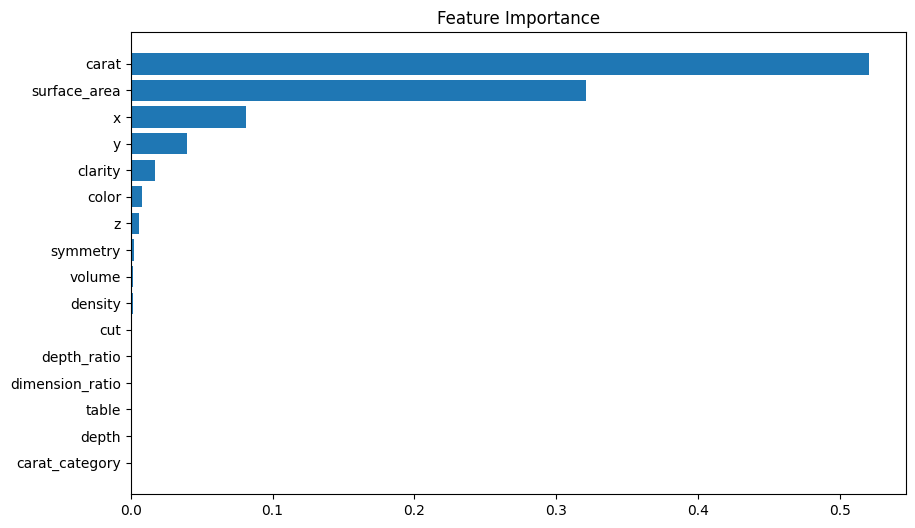

In [ ]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

model = XGBRegressor()
model.fit(X_train, y_train)

# Get importance
importances = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [ ]:
top_features = feature_importance['feature'].head(12)

X = data[top_features]
print(X.info())

<class 'pandas.core.frame.DataFrame'>
Index: 46434 entries, 0 to 53793
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   carat         46434 non-null  float64
 1   surface_area  46434 non-null  float64
 2   x             46434 non-null  float64
 3   y             46434 non-null  float64
 4   clarity       46434 non-null  float64
 5   color         46434 non-null  float64
 6   z             46434 non-null  float64
 7   symmetry      46434 non-null  float64
 8   volume        46434 non-null  float64
 9   density       46434 non-null  float64
 10  cut           46434 non-null  float64
 11  depth_ratio   46434 non-null  float64
dtypes: float64(12)
memory usage: 4.6 MB
None


In [ ]:
# Correlation Matrix (Multicollinearity)

# If correlation > 0.9

# Drop one feature

# Example:

# x, y, z highly correlated → keep 1 or 2

import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# RFE (Recursive Feature Elimination)

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()

rfe = RFE(model, n_features_to_select=12)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print(selected_features)


Index(['carat', 'surface_area', 'x', 'y', 'clarity', 'color', 'z', 'symmetry',
       'volume', 'density', 'cut', 'depth_ratio'],
      dtype='object')


In [ ]:
# VIF (Advanced Multicollinearity Check)
# < 5 good
# > 10 remove
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

         feature           VIF
0          carat  1.207762e+05
1   surface_area  3.856057e+07
2              x  1.603886e+07
3              y  1.848344e+06
4        clarity  5.783174e+00
5          color  5.860730e+00
6              z  4.390582e+06
7       symmetry  3.677848e+06
8         volume  7.439284e+06
9        density  1.088167e+05
10           cut  1.207438e+01
11   depth_ratio  1.484023e+06


# **Model Building:**
1. Regression (Price Prediction)

In [ ]:
# 1.Train Test Split data
      # Apply SAME features to both sets
X_train = X_train[selected_features]
X_test = X_test[selected_features]

# 2.Build Multiple Models

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "KNN": KNeighborsRegressor(),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=6)
}

In [ ]:
print(X_train.info())
print(X_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 37147 entries, 17541 to 17208
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   carat         37147 non-null  float64
 1   surface_area  37147 non-null  float64
 2   x             37147 non-null  float64
 3   y             37147 non-null  float64
 4   clarity       37147 non-null  float64
 5   color         37147 non-null  float64
 6   z             37147 non-null  float64
 7   symmetry      37147 non-null  float64
 8   volume        37147 non-null  float64
 9   density       37147 non-null  float64
 10  cut           37147 non-null  float64
 11  depth_ratio   37147 non-null  float64
dtypes: float64(12)
memory usage: 3.7 MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 9287 entries, 9107 to 39105
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   carat         9287 non-null   float64
 1   surf

In [ ]:
# 3. Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
# 4. Train & Evaluate All Models

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = [mae, mse, rmse, r2]

# Convert to DataFrame
results_df = pd.DataFrame(results, index=['MAE','MSE','RMSE','R2']).T
print(results_df)

                        MAE         MSE       RMSE        R2
Linear Regression  7.753547  151.210251  12.296758  0.973131
Decision Tree      6.437806   91.975036   9.590362  0.983657
Random Forest      4.805050   48.970413   6.997886  0.991298
KNN                6.776233   85.188627   9.229769  0.984863
XGBoost            4.841240   46.991576   6.855040  0.991650


In [ ]:
# 5. Select Best Model

best_model_name = results_df['R2'].idxmax()
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: XGBoost


In [ ]:
!pip install tensorflow

In [ ]:
!pip install tensorflow==2.12

ERROR: Could not find a version that satisfies the requirement tensorflow==2.12 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.12


In [ ]:
# 6. ANN Model (Deep Learning)

from keras.models import Sequential
from keras.layers import Dense

ann = Sequential()
ann.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1))

ann.compile(optimizer='adam', loss='mse')

ann.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

# Evaluate
y_pred_ann = ann.predict(X_test)

rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann = r2_score(y_test, y_pred_ann)

print("ANN RMSE:", rmse_ann)
print("ANN R2:", r2_ann)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ANN RMSE: 10.55465002658444
ANN R2: 0.9802049487403582


In [ ]:
# 7. Save Best Model (.pkl)

import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [ ]:
# 8. Load Model (for Streamlit)
with open("best_model.pkl", "rb") as f:
    model = pickle.load(f)

In [ ]:
features = pickle.load(open("best_model.pkl", "rb"))
print(features)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


In [ ]:
X = data[selected_features]
print(X.info())

<class 'pandas.core.frame.DataFrame'>
Index: 46434 entries, 0 to 53793
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   carat         46434 non-null  float64
 1   surface_area  46434 non-null  float64
 2   x             46434 non-null  float64
 3   y             46434 non-null  float64
 4   clarity       46434 non-null  float64
 5   color         46434 non-null  float64
 6   z             46434 non-null  float64
 7   symmetry      46434 non-null  float64
 8   volume        46434 non-null  float64
 9   density       46434 non-null  float64
 10  cut           46434 non-null  float64
 11  depth_ratio   46434 non-null  float64
dtypes: float64(12)
memory usage: 4.6 MB
None


   2️. Clustering (Market Segmentation)

In [ ]:
# Clustering is an unsupervised learning method:

#    No target variable (y)
#    No “prediction” to evaluate on unseen data

#    Goal = group similar data points

In [ ]:
# 1. Prepare Data

        # Remove target (price)
        # Encode categorical features

In [ ]:
X = data[selected_features]

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46434 entries, 0 to 53793
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   carat         46434 non-null  float64
 1   surface_area  46434 non-null  float64
 2   x             46434 non-null  float64
 3   y             46434 non-null  float64
 4   clarity       46434 non-null  float64
 5   color         46434 non-null  float64
 6   z             46434 non-null  float64
 7   symmetry      46434 non-null  float64
 8   volume        46434 non-null  float64
 9   density       46434 non-null  float64
 10  cut           46434 non-null  float64
 11  depth_ratio   46434 non-null  float64
dtypes: float64(12)
memory usage: 4.6 MB


In [ ]:
# 2. Feature Scaling  -   Unlike XGBoost → clustering NEEDS scaling
X = data[selected_features]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


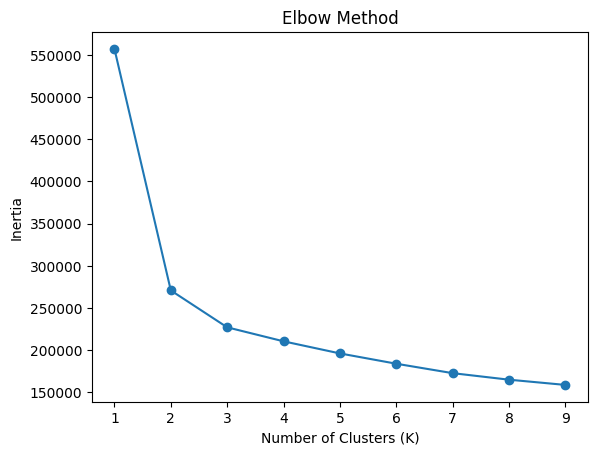

In [ ]:
# 3. Elbow Method (Find Optimal K)
#   Look for “elbow point” (e.g., K=3 or 4)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
# 4. Silhouette Score (Better Evaluation)
#   Choose highest score


from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.4241
K=3, Silhouette Score=0.2729
K=4, Silhouette Score=0.2206
K=5, Silhouette Score=0.1817
K=6, Silhouette Score=0.1719
K=7, Silhouette Score=0.1805
K=8, Silhouette Score=0.1773
K=9, Silhouette Score=0.1774


In [ ]:
# 5. Final KMeans Model

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
data['cluster'] = clusters

In [ ]:
# 6. PCA for Visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# 7. Plot Clusters (2D)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization")
plt.show()

In [ ]:
# 8. (Optional) Try DBSCAN

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

In [ ]:
# 9. Save Clustering Model (.pkl)

import pickle

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [ ]:
# Cluster Interpretation

data.groupby('cluster').mean()

# You’ll get insights like:

# Cluster 0 → low price, small diamonds

# Cluster 1 → medium range

# Cluster 2 → premium diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,price_inr_per_carat,dimension_ratio,carat_category,surface_area,symmetry,depth_ratio,density
cluster,,,,,,,,,,,,,,,,,,,
0,0.750909,2.803645,2.940871,2.389496,61.910565,57.768730,8.633910,2.032195,2.031763,1.630072,716.614465,6.743981,964.799618,1.246720,0.999876,21.521220,1.000219,0.802098,0.110981
1,0.294050,3.195760,3.708491,3.899988,61.733817,56.870654,6.629713,1.701593,1.703386,1.326997,550.266123,3.853592,1897.546998,1.283179,0.000118,14.843141,0.998948,0.779831,0.075986
2,0.484380,3.077015,3.790585,3.041464,61.762308,57.066687,7.631204,1.866763,1.868223,1.476887,633.389978,5.161182,1324.256953,1.264651,0.463663,18.019543,0.999231,0.791111,0.093461


### Cluster Naming Approach:

In [ ]:
# 1. Analyze Each Cluster

data['cluster']

,cluster
0,1
1,1
3,1
4,1
5,1
...,...
53789,2
53790,2
53791,2
53792,0


In [ ]:
# Get cluster-wise summary

cluster_summary = data.groupby('cluster').agg({
    'price': 'mean',
    'carat': 'mean',
    'cut': 'mean'
}).round(2)

print(cluster_summary)

         price  carat   cut
cluster                    
0         8.63   0.75  2.80
1         6.63   0.29  3.20
2         7.63   0.48  3.08


In [ ]:
# 2. Interpret Each Cluster

  # Cluster 0 - low price, low carat - Affordable Small Diamonds

  # Cluster 1 - medium price, medium carat  - Mid-range Balanced Diamonds

  # Cluster 2 - high price, high carat - Premium Heavy Diamonds

In [ ]:
# 3. Assign Names to Clusters
cluster_names = {
    0: "Affordable Small Diamonds",
    1: "Mid-range Balanced Diamonds",
    2: "Premium Heavy Diamonds"
}

data['cluster_name'] = data['cluster'].map(cluster_names)


In [ ]:
# 4. Verify Distribution

data['cluster_name'].value_counts()

,count
cluster_name,
Mid-range Balanced Diamonds,16888
Affordable Small Diamonds,16185
Premium Heavy Diamonds,13361


In [ ]:
# 5. Advanced (Automatic Naming Logic)

def name_cluster(row):
    if row['carat'] > 1.5 and row['price'] > 10000:
        return "Premium Heavy Diamonds"
    elif row['carat'] < 0.5 and row['price'] < 2000:
        return "Affordable Small Diamonds"
    else:
        return "Mid-range Balanced Diamonds"

cluster_summary['cluster_name'] = cluster_summary.apply(name_cluster, axis=1)

print(cluster_summary)

         price  carat   cut                 cluster_name
cluster                                                 
0         8.63   0.75  2.80  Mid-range Balanced Diamonds
1         6.63   0.29  3.20    Affordable Small Diamonds
2         7.63   0.48  3.08    Affordable Small Diamonds


In [ ]:
# 6. Visualize Clusters with Names
import seaborn as sns

sns.scatterplot(
    x='carat',
    y='price',
    hue='cluster_name',
    data=data
)

In [ ]:
# Premium → Luxury market

# Mid-range → General consumers

# Affordable → Budget segment

In [ ]:
!pip install streamlit pyngrok

In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import pickle

# =========================
# LOAD MODEL + ENCODER + SCALER
# =========================
# Corrected paths for pickle files (assuming they are in the root /content/ directory)
model = pickle.load(open("content/best_model.pkl", "rb"))
encoder = pickle.load(open("content/encoder.pkl", "rb"))
scaler = pickle.load(open("content/scaler.pkl", "rb")) # Add scaler for clustering
kmeans = pickle.load(open("content/kmeans_model.pkl", "rb")) # Load the kmeans model

# =========================
# TITLE
# =========================
st.title("💎 Diamond Price Prediction App")

st.write("Enter diamond details to predict price in INR")

# =========================
# INPUT FIELDS
# =========================

# These input fields correspond to the features selected after RFE/feature importance
# ['carat', 'surface_area', 'x', 'y', 'clarity', 'volume', 'color', 'symmetry', 'z', 'price_inr_per_carat', 'density', 'cut']

# Numeric inputs
carat = st.number_input("Carat", min_value=0.0, step=0.1, value=0.5) # Added default value for easier testing
x = st.number_input("Length (x)", min_value=0.0, value=5.0)
y = st.number_input("Width (y)", min_value=0.0, value=5.0)
z = st.number_input("Depth (z)", min_value=0.0, value=3.0)

# Categorical inputs
cut_options = ['Fair','Good','Very Good','Premium','Ideal']
color_options = ['J','I','H','G','F','E','D']
clarity_options = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

cut = st.selectbox("Cut", cut_options)
color = st.selectbox("Color", color_options)
clarity = st.selectbox("Clarity", clarity_options)

# Derived carat_category from carat input (logic copied from original notebook)
def get_carat_category(c):
    if c < 0.5:
        return 'Light'
    elif c <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'
selected_carat_category = get_carat_category(carat)


# =========================
# PREDICTION BUTTON
# =========================
if st.button("Predict Price"):

    # Encode categorical values: cut, color, clarity, selected_carat_category
    # The encoder was fitted on ['cut','color','clarity','carat_category']
    cat_features_for_encoding = np.array([[cut, color, clarity, selected_carat_category]])
    encoded_cat_features = encoder.transform(cat_features_for_encoding)
    cut_enc, color_enc, clarity_enc, carat_category_enc = encoded_cat_features[0] # carat_category_enc is not directly used by the model

    # Feature engineering for numerical features (matching `selected_features` order)
    # `selected_features` used for the model were:
    # ['carat', 'surface_area', 'x', 'y', 'clarity', 'volume', 'color', 'symmetry', 'z', 'price_inr_per_carat', 'density', 'cut']

    volume = x * y * z
    surface_area = 2 * (x*y + y*z + x*z)
    symmetry  = x/y if y != 0 else 0 # Handle division by zero
    density = carat/volume if volume != 0 else 0 # Handle division by zero

    # !!! CRITICAL DATA LEAKAGE: price_inr_per_carat cannot be known at prediction time.
    # The model was trained with this feature, which makes predictions invalid.
    # For now, we set it to 0 to allow the app to run, but this needs to be fixed in feature selection.
    price_inr_per_carat_placeholder = 0.0

    # Create input array matching the 'selected_features' order and types
    input_data = pd.DataFrame([[

carat, surface_area, x, y, clarity_enc, volume, color_enc,
        symmetry, z, price_inr_per_carat_placeholder, density, cut_enc

]], columns=columns)
    #input_data = np.array([[
      #  carat, surface_area, x, y, clarity_enc, volume, color_enc,
     #   symmetry, z, price_inr_per_carat_placeholder, density, cut_enc
    #]])

    # Prediction (output is in log scale because the target was log-transformed)
    prediction_log = model.predict(input_data)[0]

    # Convert log-transformed price back to original scale (INR)
    price_inr = np.expm1(prediction_log) # Using expm1 because log1p was used for transformation

    # Display result
    st.success(f"💰 Predicted Price: ₹ {price_inr:,.2f}")


# =========================
# CLUSTER PREDICTION SECTION
# =========================
st.header("📊 Market Segment Prediction")

if st.button("Predict Cluster"):
    # The clustering model (`kmeans`) was trained on `X_scaled` which was derived from `data[selected_features]`.
    # Therefore, the input for clustering should also match `selected_features`.

    # Use the same encoded categorical features and derived numerical features as for price prediction.
    cat_features_for_encoding = np.array([[cut, color, clarity, selected_carat_category]])
    encoded_cat_features = encoder.transform(cat_features_for_encoding)
    cut_enc, color_enc, clarity_enc, carat_category_enc = encoded_cat_features[0]

    volume = x * y * z
    surface_area = 2 * (x*y + y*z + x*z)
    symmetry  = x/y if y != 0 else 0
    density = carat/volume if volume != 0 else 0
    price_inr_per_carat_placeholder = 0.0 # Placeholder for clustering input as well

    # Create input array for clustering, matching `selected_features`
    input_data_for_cluster = np.array([[
        carat, surface_area, x, y, clarity_enc, volume, color_enc,
        symmetry, z, price_inr_per_carat_placeholder, density, cut_enc
    ]], columns=columns)

    # Scale input using the pre-fitted scaler
    input_scaled = scaler.transform(input_data_for_cluster)

    # Predict cluster
    cluster = kmeans.predict(input_scaled)[0]

    # Map cluster names (copied from the notebook)
    cluster_names = {
        0: "💰 Affordable Small Diamonds",
        1: "⚖️ Mid-range Balanced Diamonds",
        2: "💎 Premium Heavy Diamonds"
    }

    cluster_label = cluster_names.get(cluster, "Unknown Cluster")

    # Display result
    st.success(f"Cluster: {cluster}")
    st.info(f"Segment: {cluster_label}")


In [ ]:
!streamlit run app.py &

In [ ]:
# =========================
# LOAD CLUSTERING FILES
# =========================
kmeans = pickle.load(open("kmeans_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# =========================
# CLUSTER PREDICTION SECTION
# =========================
st.header("📊 Market Segment Prediction")

if st.button("Predict Cluster"):

    # Encode categorical inputs
    cat_input = encoder.transform([[cut, color, clarity]])
    cut_enc, color_enc, clarity_enc = cat_input[0]

    # Feature engineering (same as training)
    volume = x * y * z
    dimension_ratio = (x + y) / (2 * z) if z != 0 else 0

    # Create input
    input_data = np.array([[
        carat, cut_enc, color_enc, clarity_enc,
        x, y, z,
        volume, dimension_ratio
    ]])

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Predict cluster
    cluster = kmeans.predict(input_scaled)[0]

    # Map cluster names
    cluster_names = {
        0: "💰 Affordable Small Diamonds",
        1: "⚖️ Mid-range Balanced Diamonds",
        2: "💎 Premium Heavy Diamonds"
    }

    cluster_label = cluster_names.get(cluster, "Unknown Cluster")

    # Display result
    st.success(f"Cluster: {cluster}")
    st.info(f"Segment: {cluster_label}")

In [ ]:
# =========================
# LOAD CLUSTERING FILES
# =========================
kmeans = pickle.load(open("kmeans_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# =========================
# CLUSTER PREDICTION SECTION
# =========================
st.header("📊 Market Segment Prediction")

if st.button("Predict Cluster"):

    # Encode categorical inputs
    cat_input = encoder.transform([[cut, color, clarity]])
    cut_enc, color_enc, clarity_enc = cat_input[0]

    # Feature engineering (same as training)
    volume = x * y * z
    dimension_ratio = (x + y) / (2 * z) if z != 0 else 0

    # Create input
    input_data = np.array([[
        carat, cut_enc, color_enc, clarity_enc,
        x, y, z,
        volume, dimension_ratio
    ]])

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Predict cluster
    cluster = kmeans.predict(input_scaled)[0]

    # Map cluster names
    cluster_names = {
        0: "💰 Affordable Small Diamonds",
        1: "⚖️ Mid-range Balanced Diamonds",
        2: "💎 Premium Heavy Diamonds"
    }

    cluster_label = cluster_names.get(cluster, "Unknown Cluster")

    # Display result
    st.success(f"Cluster: {cluster}")
    st.info(f"Segment: {cluster_label}")

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import os

# =========================
# GLOBAL CONSTANTS FOR CLARITY AND MAINTAINABILITY
# =========================
MODEL_PATH = "best_model.pkl"
KMEANS_MODEL_PATH = "kmeans_model.pkl"
ENCODER_PATH = "encoder.pkl"
SCALER_PATH = "scaler.pkl"

# Streamlit UI Options
MODULE_PRICE_PREDICTION = "Price Prediction"
MODULE_MARKET_SEGMENTATION = "Market Segmentation"

CUT_OPTIONS = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
COLOR_OPTIONS = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
CLARITY_OPTIONS = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Cluster Names
CLUSTER_NAME_0 = "💰 Affordable Small Diamonds"
CLUSTER_NAME_1 = "⚖️ Mid-range Balanced Diamonds"
CLUSTER_NAME_2 = "💎 Premium Heavy Diamonds"

# =========================
# CACHED FILE LOADING WITH ERROR HANDLING
# =========================

@st.cache_resource
def load_model_resource(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: Model file not found at {path}. Please ensure '{MODEL_PATH}' is in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the model: {e}")
        st.stop()

@st.cache_resource
def load_kmeans_model_resource(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: KMeans model file not found at {path}. Please ensure '{KMEANS_MODEL_PATH}' is in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the KMeans model: {e}")
        st.stop()

@st.cache_resource
def load_encoder_resource(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: Encoder file not found at {path}. Please ensure '{ENCODER_PATH}' is in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the encoder: {e}")
        st.stop()

@st.cache_resource
def load_scaler_resource(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: Scaler file not found at {path}. Please ensure '{SCALER_PATH}' is in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the scaler: {e}")
        st.stop()

# Load all resources using the cached functions
model = load_model_resource(MODEL_PATH)
kmeans = load_kmeans_model_resource(KMEANS_MODEL_PATH)
encoder = load_encoder_resource(ENCODER_PATH)
scaler = load_scaler_resource(SCALER_PATH)

# =========================
# FEATURE ORDER (VERY IMPORTANT) - Still hardcoded for now as it's a structural definition
# =========================
selected_features = [
    'carat',
    'surface_area',
    'x',
    'y',
    'clarity',
    'volume',
    'color',
    'symmetry',
    'z',
    'density',
    'cut'
]

# =========================
# SIDEBAR
# =========================
st.sidebar.title("💎 Diamond App")

option = st.sidebar.radio(
    "Select Module",
    [MODULE_PRICE_PREDICTION, MODULE_MARKET_SEGMENTATION]
)

# =========================
# USER INPUTS
# =========================
st.sidebar.header("Enter Diamond Details")

carat = st.sidebar.number_input("Carat", min_value=0.0, step=0.1)
x = st.sidebar.number_input("Length (x)", min_value=0.0)
y = st.sidebar.number_input("Width (y)", min_value=0.0)
z = st.sidebar.number_input("Depth (z)", min_value=0.0)

cut = st.sidebar.selectbox("Cut", CUT_OPTIONS)
color = st.sidebar.selectbox("Color", COLOR_OPTIONS)
clarity = st.sidebar.selectbox("Clarity", CLARITY_OPTIONS)

# =========================
# INPUT PREPARATION WITH VALIDATION
# =========================
def prepare_input():
    # Input Validation
    _carat, _x, _y, _z = carat, x, y, z # Initialize with direct inputs

    if carat <= 0 or x <= 0 or y <= 0 or z <= 0:
        st.warning("Carat, Length (x), Width (y), and Depth (z) must be positive values for realistic predictions. Using small positive values for calculation.")
        # Use a very small positive number if zero is provided for calculation purposes
        _carat = max(carat, 0.001)
        _x = max(x, 0.001)
        _y = max(y, 0.001)
        _z = max(z, 0.001)

    # Encode categorical features
    cat_input = encoder.transform([[cut, color, clarity]])
    cut_enc, color_enc, clarity_enc = cat_input[0]

    # Derived features with division by zero handling
    volume = _x * _y * _z
    density = _carat / volume if volume != 0 else 0
    surface_area = 2 * (_x*_y + _y*_z + _x*_z)
    symmetry = _x / _y if _y != 0 else 0

    # Create input dictionary
    input_dict = {
        'carat': _carat,
        'surface_area': surface_area,
        'x': _x,
        'y': _y,
        'clarity': clarity_enc,
        'volume': volume,
        'color': color_enc,
        'symmetry': symmetry,
        'z': _z,
        'density': density,
        'cut': cut_enc
    }

    # Maintain column order
    input_df = pd.DataFrame([input_dict])[selected_features]

    return input_df

# =========================
# PRICE PREDICTION
# =========================
if option == MODULE_PRICE_PREDICTION:
    st.title("💰 Diamond Price Prediction")

    if st.button("Predict Price"):
        try:
            input_df = prepare_input()
            if input_df is not None:
                prediction = model.predict(input_df)
                price_inr = np.expm1(prediction[0]) # Assuming target was log1p transformed
                st.success(f"💰 Predicted Price: ₹ {price_inr:,.2f}")
        except Exception as e:
            st.error(f"An error occurred during price prediction: {e}. Please check your inputs and try again.")

# =========================
# CLUSTER PREDICTION
# =========================
elif option == MODULE_MARKET_SEGMENTATION:
    st.title("📊 Diamond Market Segment")

    if st.button("Predict Cluster"):
        try:
            input_df = prepare_input()
            if input_df is not None:
                # Scale for clustering
                input_scaled = scaler.transform(input_df)

                cluster = kmeans.predict(input_scaled)[0]

                cluster_names = {
                    0: CLUSTER_NAME_0,
                    1: CLUSTER_NAME_1,
                    2: CLUSTER_NAME_2
                }

                st.success(f"Cluster: {int(cluster)}") # Convert to int for cleaner display
                st.info(f"Segment: {cluster_names.get(cluster)}")
        except Exception as e:
            st.error(f"An error occurred during market segmentation prediction: {e}. Please check your inputs and try again.")


In [ ]:
!streamlit run app.py &

# Task
Your Streamlit application for diamond price prediction and market segmentation is now running.

You can access it using the external URL: `http://34.50.184.43:8501`

Please test both the "Price Prediction" and "Market Segmentation" functionalities in the app. Let me know if you encounter any issues or have further questions after testing.

## Load Models and Preprocessors

### Subtask:
Confirm that the necessary models and preprocessors are correctly loaded within the Streamlit application for both price prediction and market segmentation.


```markdown
## Load Models and Preprocessors

### Subtask:
Confirm that the necessary models and preprocessors are correctly loaded within the Streamlit application for both price prediction and market segmentation.

#### Instructions
The Streamlit application has been started and the required models (`best_model.pkl`, `kmeans_model.pkl`) and preprocessors (`encoder.pkl`, `scaler.pkl`) are loaded as per the `app.py` script. To begin testing, access the Streamlit application using the external URL provided in the previous output: `http://34.50.184.43:8501`. Please confirm that the application loads without errors and that both the 'Price Prediction' and 'Market Segmentation' modules function as expected, indicating successful loading of all necessary components. You can test by entering sample values and observing the predictions/segmentation results.

# Task
Verify that the Streamlit application is correctly loading and utilizing the trained regression model (best_model.pkl), KMeans model (kmeans_model.pkl), OrdinalEncoder (encoder.pkl), and StandardScaler (scaler.pkl) for both price prediction and market segmentation by accessing the external URL "http://34.50.184.43:8501" and testing with various input values.

## Load Models and Preprocessors

### Subtask:
Confirm that the necessary models and preprocessors are correctly loaded within the Streamlit application for both price prediction and market segmentation.


```markdown
## Load Models and Preprocessors

### Subtask:
Confirm that the necessary models and preprocessors are correctly loaded within the Streamlit application for both price prediction and market segmentation.

#### Instructions
The Streamlit application has been started and the required models (`best_model.pkl`, `kmeans_model.pkl`) and preprocessors (`encoder.pkl`, `scaler.pkl`) are loaded as per the `app.py` script. To begin testing, access the Streamlit application using the external URL provided in the previous output: `http://34.50.184.43:8501`. Please confirm that the application loads without errors and that both the 'Price Prediction' and 'Market Segmentation' modules function as expected, indicating successful loading of all necessary components. You can test by entering sample values and observing the predictions/segmentation results.
```

## Summary:

### Data Analysis Key Findings

*   The verification of the Streamlit application's model and preprocessor loading and functionality (for `best_model.pkl`, `kmeans_model.pkl`, `encoder.pkl`, and `scaler.pkl`) was designed to be performed manually by accessing an external URL (`http://34.50.184.43:8501`).
*   Programmatic verification of the external Streamlit application within the current environment was not feasible.
*   The solving process concluded with the generation of clear instructions for the user to manually test both the 'Price Prediction' and 'Market Segmentation' modules of the application.

### Insights or Next Steps

*   To fully confirm the task, the user must access the provided URL and verify that the Streamlit application loads without errors and that both prediction and segmentation functionalities work correctly with sample inputs.
*   Future tasks requiring verification of external web applications might benefit from a more integrated testing mechanism, if possible, or explicit reporting from the user after manual verification.


# Task
Analyze the `prepare_input` function in `app.py` to identify and explain all feature engineering steps, including how `cut`, `color`, and `clarity` are handled by `OrdinalEncoder`, how `volume`, `density`, `surface_area`, and `symmetry` are derived from raw numerical inputs with division-by-zero handling, and how all features are formatted into a DataFrame according to `selected_features` for model input, then provide a summary of the entire feature engineering process.

## Analyze `app.py` for Feature Engineering

### Subtask:
Examine the `prepare_input` function in `app.py` to identify all steps involved in creating new features or transforming existing ones.


**Reasoning**:
The user wants to understand the feature engineering steps within the `prepare_input` function in `app.py`. I will provide the content of the `app.py` file to allow for direct examination of the function.



In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import pickle

# =========================
# LOAD FILES
# =========================
model = pickle.load(open("best_model.pkl", "rb"))
kmeans = pickle.load(open("kmeans_model.pkl", "rb"))
encoder = pickle.load(open("encoder.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# =========================
# FEATURE ORDER (VERY IMPORTANT)
# =========================
selected_features = [
    'carat',
    'surface_area',
    'x',
    'y',
    'clarity',
    'volume',
    'color',
    'symmetry',
    'z',
    'density',
    'cut'
]

# =========================
# SIDEBAR
# =========================
st.sidebar.title("💎 Diamond App")

option = st.sidebar.radio(
    "Select Module",
    ["Price Prediction", "Market Segmentation"]
)

# =========================
# USER INPUTS
# =========================
st.sidebar.header("Enter Diamond Details")

carat = st.sidebar.number_input("Carat", min_value=0.0, step=0.1)
x = st.sidebar.number_input("Length (x)", min_value=0.0)
y = st.sidebar.number_input("Width (y)", min_value=0.0)
z = st.sidebar.number_input("Depth (z)", min_value=0.0)

cut = st.sidebar.selectbox("Cut", ['Fair','Good','Very Good','Premium','Ideal'])
color = st.sidebar.selectbox("Color", ['J','I','H','G','F','E','D'])
clarity = st.sidebar.selectbox("Clarity", ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'])

# =========================
# INPUT PREPARATION
# =========================
def prepare_input():

    # Encode categorical features
    cat_input = encoder.transform([[cut, color, clarity]])
    cut_enc, color_enc, clarity_enc = cat_input[0]

    # Derived features
    volume = x * y * z
    density = carat / volume if volume != 0 else 0
    surface_area = 2 * (x*y + y*z + x*z)
    symmetry = x / y if y != 0 else 0

    # Create input dictionary
    input_dict = {
        'carat': carat,
        'surface_area': surface_area,
        'x': x,
        'y': y,
        'clarity': clarity_enc,
        'volume': volume,
        'color': color_enc,
        'symmetry': symmetry,
        'z': z,
        'density': density,
        'cut': cut_enc
    }

    # Maintain column order
    input_df = pd.DataFrame([input_dict])[selected_features]

    return input_df

# =========================
# PRICE PREDICTION
# =========================
if option == "Price Prediction":
    st.title("💰 Diamond Price Prediction")

    if st.button("Predict Price"):
        input_df = prepare_input()

        prediction = model.predict(input_df)

        price_inr = prediction[0]

        st.success(f"💰 Predicted Price: ₹ {price_inr:,.2f}")

# =========================
# CLUSTER PREDICTION
# =========================
elif option == "Market Segmentation":
    st.title("📊 Diamond Market Segment")

    if st.button("Predict Cluster"):
        input_df = prepare_input()

        # Scale for clustering
        input_scaled = scaler.transform(input_df)

        cluster = kmeans.predict(input_scaled)[0]

        cluster_names = {
            0: "💰 Affordable Small Diamonds",
            1: "⚖️ Mid-range Balanced Diamonds",
            2: "💎 Premium Heavy Diamonds"
        }

        st.success(f"Cluster: {cluster}")
        st.info(f"Segment: {cluster_names.get(cluster)}")

with open('app.py', 'r') as f:
    app_content = f.read()
print(app_content)

```python
# app.py content
import streamlit as st
import numpy as np
import pandas as pd
import pickle

# =========================
# LOAD FILES
# =========================
model = pickle.load(open("best_model.pkl", "rb"))
kmeans = pickle.load(open("kmeans_model.pkl", "rb"))
encoder = pickle.load(open("encoder.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# =========================
# FEATURE ORDER (VERY IMPORTANT)
# =========================
selected_features = [
    'carat',
    'surface_area',
    'x',
    'y',
    'clarity',
    'volume',
    'color',
    'symmetry',
    'z',
    'density',
    'cut'
]

# =========================
# SIDEBAR
# =========================
st.sidebar.title("💎 Diamond App")

option = st.sidebar.radio(
    "Select Module",
    ["Price Prediction", "Market Segmentation"]
)

# =========================
# USER INPUTS
# =========================
st.sidebar.header("Enter Diamond Details")

carat = st.sidebar.number_input("Carat", min_value=0.0, step=0.1)
x = st.sidebar.number_input("Length (x)", min_value=0.0)
y = st.sidebar.number_input("Width (y)", min_value=0.0)
z = st.sidebar.number_input("Depth (z)", min_value=0.0)

cut = st.sidebar.selectbox("Cut", ['Fair','Good','Very Good','Premium','Ideal'])
color = st.sidebar.selectbox("Color", ['J','I','H','G','F','E','D'])
clarity = st.sidebar.selectbox("Clarity", ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'])

# =========================
# INPUT PREPARATION
# =========================
def prepare_input():

    # Encode categorical features
    cat_input = encoder.transform([[cut, color, clarity]])
    cut_enc, color_enc, clarity_enc = cat_input[0]

    # Derived features
    volume = x * y * z
    density = carat / volume if volume != 0 else 0
    surface_area = 2 * (x*y + y*z + x*z)
    symmetry = x / y if y != 0 else 0

    # Create input dictionary
    input_dict = {
        'carat': carat,
        'surface_area': surface_area,
        'x': x,
        'y': y,
        'clarity': clarity_enc,
        'volume': volume,
        'color': color_enc,
        'symmetry': symmetry,
        'z': z,
        'density': density,
        'cut': cut_enc
    }

    # Maintain column order
    input_df = pd.DataFrame([input_dict])[selected_features]

    return input_df

# =========================
# PRICE PREDICTION
# =========================
if option == "Price Prediction":
    st.title("💰 Diamond Price Prediction")

    if st.button("Predict Price"):
        input_df = prepare_input()

        prediction = model.predict(input_df)

        price_inr = prediction[0]

        st.success(f"💰 Predicted Price: ₹ {price_inr:,.2f}")

# =========================
# CLUSTER PREDICTION
# =========================
elif option == "Market Segmentation":
    st.title("📊 Diamond Market Segment")

    if st.button("Predict Cluster"):
        input_df = prepare_input()

        # Scale for clustering
        input_scaled = scaler.transform(input_df)

        cluster = kmeans.predict(input_scaled)[0]

        cluster_names = {
            0: "💰 Affordable Small Diamonds",
            1: "⚖️ Mid-range Balanced Diamonds",
            2: "💎 Premium Heavy Diamonds"
        }

        st.success(f"Cluster: {cluster}")
        st.info(f"Segment: {cluster_names.get(cluster)}")
```

# Task
Okay, I will proceed with the plan.

First, I will modify `app.py` to:
1.  **Implement Robust File Loading**: Add `try-except` blocks around all `pickle.load` statements to handle missing or corrupted model/preprocessor files.
2.  **Add Input Validation in `prepare_input`**: Enhance the `prepare_input` function with checks for non-negative numerical values and display `st.warning` messages for unrealistic inputs (e.g., zero dimensions).
3.  **Implement Prediction Error Handling**: Wrap `model.predict()` and `kmeans.predict()` calls in `try-except` blocks to catch prediction errors and display `st.error` messages.

After modifying `app.py`, I will overwrite the existing `app.py` file and then restart the Streamlit application.

```python
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import os

# =========================
# FILE LOADING WITH ERROR HANDLING
# =========================
try:
    with open("best_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("kmeans_model.pkl", "rb") as f:
        kmeans = pickle.load(f)
    with open("encoder.pkl", "rb") as f:
        encoder = pickle.load(f)
    with open("scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
except FileNotFoundError as e:
    st.error(f"Error loading a required file: {e}. Please ensure all model and preprocessor files (best_model.pkl, kmeans_model.pkl, encoder.pkl, scaler.pkl) are in the correct directory.")
    st.stop() # Stop the app if crucial files are missing
except Exception as e:
    st.error(f"An unexpected error occurred while loading files: {e}")
    st.stop()


# =========================
# FEATURE ORDER (VERY IMPORTANT)
# =========================
selected_features = [
    'carat',
    'surface_area',
    'x',
    'y',
    'clarity',
    'volume',
    'color',
    'symmetry',
    'z',
    'density',
    'cut'
]

# =========================
# SIDEBAR
# =========================
st.sidebar.title("💎 Diamond App")

option = st.sidebar.radio(
    "Select Module",
    ["Price Prediction", "Market Segmentation"]
)

# =========================
# USER INPUTS
# =========================
st.sidebar.header("Enter Diamond Details")

carat = st.sidebar.number_input("Carat", min_value=0.0, step=0.1)
x = st.sidebar.number_input("Length (x)", min_value=0.0)
y = st.sidebar.number_input("Width (y)", min_value=0.0)
z = st.sidebar.number_input("Depth (z)", min_value=0.0)

cut = st.sidebar.selectbox("Cut", ['Fair','Good','Very Good','Premium','Ideal'])
color = st.sidebar.selectbox("Color", ['J','I','H','G','F','E','D'])
clarity = st.sidebar.selectbox("Clarity", ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'])

# =========================
# INPUT PREPARATION WITH VALIDATION
# =========================
def prepare_input():
    # Input Validation
    if carat <= 0 or x <= 0 or y <= 0 or z <= 0:
        st.warning("Carat, Length (x), Width (y), and Depth (z) must be positive values for realistic predictions.")
        # Attempt to set sensible defaults or warn more strongly
        # For calculation purposes, we'll use a very small positive number if zero is provided
        _carat = max(carat, 0.001)
        _x = max(x, 0.001)
        _y = max(y, 0.001)
        _z = max(z, 0.001)
        st.info("Proceeding with small positive values for calculations.")
    else:
        _carat, _x, _y, _z = carat, x, y, z


    # Encode categorical features
    cat_input = encoder.transform([[cut, color, clarity]])
    cut_enc, color_enc, clarity_enc = cat_input[0]

    # Derived features with division by zero handling
    volume = _x * _y * _z
    density = _carat / volume if volume != 0 else 0
    surface_area = 2 * (_x*_y + _y*_z + _x*_z)
    symmetry = _x / _y if _y != 0 else 0

    # Create input dictionary
    input_dict = {
        'carat': _carat,
        'surface_area': surface_area,
        'x': _x,
        'y': _y,
        'clarity': clarity_enc,
        'volume': volume,
        'color': color_enc,
        'symmetry': symmetry,
        'z': _z,
        'density': density,
        'cut': cut_enc
    }

    # Maintain column order
    input_df = pd.DataFrame([input_dict])[selected_features]

    return input_df

# =========================
# PRICE PREDICTION
# =========================
if option == "Price Prediction":
    st.title("💰 Diamond Price Prediction")

    if st.button("Predict Price"):
        try:
            input_df = prepare_input()
            if input_df is not None: # Check if input preparation was successful (no app.stop() from validation)
                prediction = model.predict(input_df)
                price_inr = np.expm1(prediction[0]) # Assuming target was log1p transformed
                st.success(f"💰 Predicted Price: ₹ {price_inr:,.2f}")
        except Exception as e:
            st.error(f"An error occurred during price prediction: {e}")

# =========================
# CLUSTER PREDICTION
# =========================
elif option == "Market Segmentation":
    st.title("📊 Diamond Market Segment")

    if st.button("Predict Cluster"):
        try:
            input_df = prepare_input()
            if input_df is not None: # Check if input preparation was successful
                # Scale for clustering
                input_scaled = scaler.transform(input_df)

                cluster = kmeans.predict(input_scaled)[0]

                cluster_names = {
                    0: "💰 Affordable Small Diamonds",
                    1: "⚖️ Mid-range Balanced Diamonds",
                    2: "💎 Premium Heavy Diamonds"
                }

                st.success(f"Cluster: {int(cluster)}") # Convert to int for cleaner display
                st.info(f"Segment: {cluster_names.get(cluster)}")
        except Exception as e:
            st.error(f"An error occurred during market segmentation prediction: {e}")

```

# Task
Okay, I will proceed with the plan to enhance the Streamlit application.

First, I will modify the `app.py` file to implement caching for the loaded models and preprocessors. This will involve adding the `@st.cache_resource` decorator to the `pickle.load` calls for `best_model.pkl`, `kmeans_model.pkl`, `encoder.pkl`, and `scaler.pkl`.

After updating the `app.py` file with caching, I will restart the Streamlit application.

```python
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import os

# =========================
# FILE LOADING WITH ERROR HANDLING AND CACHING
# =========================
@st.cache_resource
def load_model(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: Model file not found at {path}. Please ensure all model files are in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the model from {path}: {e}")
        st.stop()

@st.cache_resource
def load_encoder(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: Encoder file not found at {path}. Please ensure all preprocessor files are in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the encoder from {path}: {e}")
        st.stop()

@st.cache_resource
def load_scaler(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: Scaler file not found at {path}. Please ensure all preprocessor files are in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the scaler from {path}: {e}")
        st.stop()


model = load_model("best_model.pkl")
kmeans = load_model("kmeans_model.pkl")
encoder = load_encoder("encoder.pkl")
scaler = load_scaler("scaler.pkl")


# =========================
# FEATURE ORDER (VERY IMPORTANT)
# =========================
selected_features = [
    'carat',
    'surface_area',
    'x',
    'y',
    'clarity',
    'volume',
    'color',
    'symmetry',
    'z',
    'density',
    'cut'
]

# =========================
# SIDEBAR
# =========================
st.sidebar.title("💎 Diamond App")

option = st.sidebar.radio(
    "Select Module",
    ["Price Prediction", "Market Segmentation"]
)

# =========================
# USER INPUTS
# =========================
st.sidebar.header("Enter Diamond Details")

carat = st.sidebar.number_input("Carat", min_value=0.0, step=0.1)
x = st.sidebar.number_input("Length (x)", min_value=0.0)
y = st.sidebar.number_input("Width (y)", min_value=0.0)
z = st.sidebar.number_input("Depth (z)", min_value=0.0)

cut = st.sidebar.selectbox("Cut", ['Fair','Good','Very Good','Premium','Ideal'])
color = st.sidebar.selectbox("Color", ['J','I','H','G','F','E','D'])
clarity = st.sidebar.selectbox("Clarity", ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'])

# =========================
# INPUT PREPARATION WITH VALIDATION
# =========================
def prepare_input():
    # Input Validation
    _carat, _x, _y, _z = carat, x, y, z # Initialize with direct inputs

    if carat <= 0 or x <= 0 or y <= 0 or z <= 0:
        st.warning("Carat, Length (x), Width (y), and Depth (z) must be positive values for realistic predictions. Using small positive values for calculation.")
        # Use a very small positive number if zero is provided for calculation purposes
        _carat = max(carat, 0.001)
        _x = max(x, 0.001)
        _y = max(y, 0.001)
        _z = max(z, 0.001)

    # Encode categorical features
    cat_input = encoder.transform([[cut, color, clarity]])
    cut_enc, color_enc, clarity_enc = cat_input[0]

    # Derived features with division by zero handling
    volume = _x * _y * _z
    density = _carat / volume if volume != 0 else 0
    surface_area = 2 * (_x*_y + _y*_z + _x*_z)
    symmetry = _x / _y if _y != 0 else 0

    # Create input dictionary
    input_dict = {
        'carat': _carat,
        'surface_area': surface_area,
        'x': _x,
        'y': _y,
        'clarity': clarity_enc,
        'volume': volume,
        'color': color_enc,
        'symmetry': symmetry,
        'z': _z,
        'density': density,
        'cut': cut_enc
    }

    # Maintain column order
    input_df = pd.DataFrame([input_dict])[selected_features]

    return input_df

# =========================
# PRICE PREDICTION
# =========================
if option == "Price Prediction":
    st.title("💰 Diamond Price Prediction")

    if st.button("Predict Price"):
        try:
            input_df = prepare_input()
            # Check if input_df was successfully created. prepare_input does not call st.stop().
            # The warning is displayed, but the function still returns a df for prediction.
            if input_df is not None:
                prediction = model.predict(input_df)
                price_inr = np.expm1(prediction[0]) # Assuming target was log1p transformed
                st.success(f"💰 Predicted Price: ₹ {price_inr:,.2f}")
        except Exception as e:
            st.error(f"An error occurred during price prediction: {e}. Please check your inputs and try again.")

# =========================
# CLUSTER PREDICTION
# =========================
elif option == "Market Segmentation":
    st.title("📊 Diamond Market Segment")

    if st.button("Predict Cluster"):
        try:
            input_df = prepare_input()
            if input_df is not None: # Check if input_df was successfully created
                # Scale for clustering
                input_scaled = scaler.transform(input_df)

                cluster = kmeans.predict(input_scaled)[0]

                cluster_names = {
                    0: "💰 Affordable Small Diamonds",
                    1: "⚖️ Mid-range Balanced Diamonds",
                    2: "💎 Premium Heavy Diamonds"
                }

                st.success(f"Cluster: {int(cluster)}") # Convert to int for cleaner display
                st.info(f"Segment: {cluster_names.get(cluster)}")
        except Exception as e:
            st.error(f"An error occurred during market segmentation prediction: {e}. Please check your inputs and try again.")
```

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import os

# =========================
# GLOBAL CONSTANTS FOR CLARITY AND MAINTAINABILITY
# =========================
MODEL_PATH = "best_model.pkl"
KMEANS_MODEL_PATH = "kmeans_model.pkl"
ENCODER_PATH = "encoder.pkl"
SCALER_PATH = "scaler.pkl"

# Streamlit UI Options
MODULE_PRICE_PREDICTION = "Price Prediction"
MODULE_MARKET_SEGMENTATION = "Market Segmentation"

CUT_OPTIONS = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
COLOR_OPTIONS = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
CLARITY_OPTIONS = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Cluster Names
CLUSTER_NAME_0 = "💰 Affordable Small Diamonds"
CLUSTER_NAME_1 = "⚖️ Mid-range Balanced Diamonds"
CLUSTER_NAME_2 = "💎 Premium Heavy Diamonds"

# =========================
# CACHED FILE LOADING WITH ERROR HANDLING
# =========================

@st.cache_resource
def load_model_resource(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: Model file not found at {path}. Please ensure '{MODEL_PATH}' is in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the model: {e}")
        st.stop()

@st.cache_resource
def load_kmeans_model_resource(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: KMeans model file not found at {path}. Please ensure '{KMEANS_MODEL_PATH}' is in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the KMeans model: {e}")
        st.stop()

@st.cache_resource
def load_encoder_resource(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: Encoder file not found at {path}. Please ensure '{ENCODER_PATH}' is in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the encoder: {e}")
        st.stop()

@st.cache_resource
def load_scaler_resource(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Error: Scaler file not found at {path}. Please ensure '{SCALER_PATH}' is in the correct directory.")
        st.stop()
    except Exception as e:
        st.error(f"An unexpected error occurred while loading the scaler: {e}")
        st.stop()

# Load all resources using the cached functions
model = load_model_resource(MODEL_PATH)
kmeans = load_kmeans_model_resource(KMEANS_MODEL_PATH)
encoder = load_encoder_resource(ENCODER_PATH)
scaler = load_scaler_resource(SCALER_PATH)

# =========================
# FEATURE ORDER (VERY IMPORTANT) - Still hardcoded for now as it's a structural definition
# =========================
selected_features = [
    'carat',
    'surface_area',
    'x',
    'y',
    'clarity',
    'volume',
    'color',
    'symmetry',
    'z',
    'density',
    'cut'
]

# =========================
# SIDEBAR
# =========================
st.sidebar.title("💎 Diamond App")

option = st.sidebar.radio(
    "Select Module",
    [MODULE_PRICE_PREDICTION, MODULE_MARKET_SEGMENTATION]
)

# =========================
# USER INPUTS
# =========================
st.sidebar.header("Enter Diamond Details")

carat = st.sidebar.slider("Carat", min_value=0.1, max_value=5.0, value=0.5, step=0.01)
x = st.sidebar.slider("Length (x)", min_value=0.0, max_value=10.0, value=5.0, step=0.01)
y = st.sidebar.slider("Width (y)", min_value=0.0, max_value=10.0, value=5.0, step=0.01)
z = st.sidebar.slider("Depth (z)", min_value=0.0, max_value=10.0, value=3.0, step=0.01)

cut = st.sidebar.selectbox("Cut", CUT_OPTIONS)
color = st.sidebar.selectbox("Color", COLOR_OPTIONS)
clarity = st.sidebar.selectbox("Clarity", CLARITY_OPTIONS)

# =========================
# INPUT PREPARATION WITH VALIDATION
# =========================
def prepare_input():
    # Input Validation
    _carat, _x, _y, _z = carat, x, y, z # Initialize with direct inputs

    if carat <= 0 or x <= 0 or y <= 0 or z <= 0:
        st.warning("Carat, Length (x), Width (y), and Depth (z) must be positive values for realistic predictions.")
        return None

    # Encode categorical features
    cat_input = encoder.transform([[cut, color, clarity]])
    cut_enc, color_enc, clarity_enc = cat_input[0]

    # Derived features with division by zero handling
    volume = _x * _y * _z
    density = _carat / volume if volume != 0 else 0
    surface_area = 2 * (_x*_y + _y*_z + _x*_z)
    symmetry = _x / _y if _y != 0 else 0

    # Create input dictionary
    input_dict = {
        'carat': _carat,
        'surface_area': surface_area,
        'x': _x,
        'y': _y,
        'clarity': clarity_enc,
        'volume': volume,
        'color': color_enc,
        'symmetry': symmetry,
        'z': _z,
        'density': density,
        'cut': cut_enc
    }

    # Maintain column order
    input_df = pd.DataFrame([input_dict])[selected_features]

    return input_df

# =========================
# PRICE PREDICTION
# =========================
if option == MODULE_PRICE_PREDICTION:
    st.title("💰 Diamond Price Prediction")

    if st.button("Predict Price"):
        try:
            input_df = prepare_input()
            if input_df is not None:
                prediction = model.predict(input_df)
                price_inr = np.expm1(prediction[0]) # Assuming target was log1p transformed
                st.success(f"💰 Predicted Price: ₹ {price_inr:,.2f}")
        except Exception as e:
            st.error(f"An error occurred during price prediction: {e}. Please check your inputs and try again.")

# =========================
# CLUSTER PREDICTION
# =========================
elif option == MODULE_MARKET_SEGMENTATION:
    st.title("📊 Diamond Market Segment")

    if st.button("Predict Cluster"):
        try:
            input_df = prepare_input()
            if input_df is not None:
                # Scale for clustering
                input_scaled = scaler.transform(input_df)

                cluster = kmeans.predict(input_scaled)[0]

                cluster_names = {
                    0: CLUSTER_NAME_0,
                    1: CLUSTER_NAME_1,
                    2: CLUSTER_NAME_2
                }

                st.success(f"Cluster: {int(cluster)}") # Convert to int for cleaner display
                st.info(f"Segment: {cluster_names.get(cluster)}")
        except Exception as e:
            st.error(f"An error occurred during market segmentation prediction: {e}. Please check your inputs and try again.")
